# Mplchart Tests

In [1]:
import yfinance as yf

from mplchart.chart import Chart
from mplchart.primitives import Candlesticks, Volume, Swings
from mplchart.indicators import SMA, EMA, WMA, HMA, DEMA, ROC, RSI, MACD, DMI, STOCH, BBANDS, KELTNER
from mplchart.utils import normalize_prices

In [2]:
ticker = "AAPL"
prices = normalize_prices(yf.Ticker(ticker).history(period="5y"))
prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1255 entries, 2021-07-19 00:00:00-04:00 to 2026-07-17 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   open          1255 non-null   float64
 1   high          1255 non-null   float64
 2   low           1255 non-null   float64
 3   close         1255 non-null   float64
 4   volume        1255 non-null   int64  
 5   dividends     1255 non-null   float64
 6   stock splits  1255 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 78.4 KB


In [3]:
prices.rename(columns=str.lower)[["high", "low", "close"]].mean(axis=1)



date
2021-07-19 00:00:00-04:00    139.126358
2021-07-20 00:00:00-04:00    141.732154
2021-07-21 00:00:00-04:00    141.715953
2021-07-22 00:00:00-04:00    143.226794
2021-07-23 00:00:00-04:00    144.328282
                                ...    
2026-07-13 00:00:00-04:00    318.846670
2026-07-14 00:00:00-04:00    314.319997
2026-07-15 00:00:00-04:00    324.516673
2026-07-16 00:00:00-04:00    331.576670
2026-07-17 00:00:00-04:00    332.576660
Length: 1255, dtype: float64

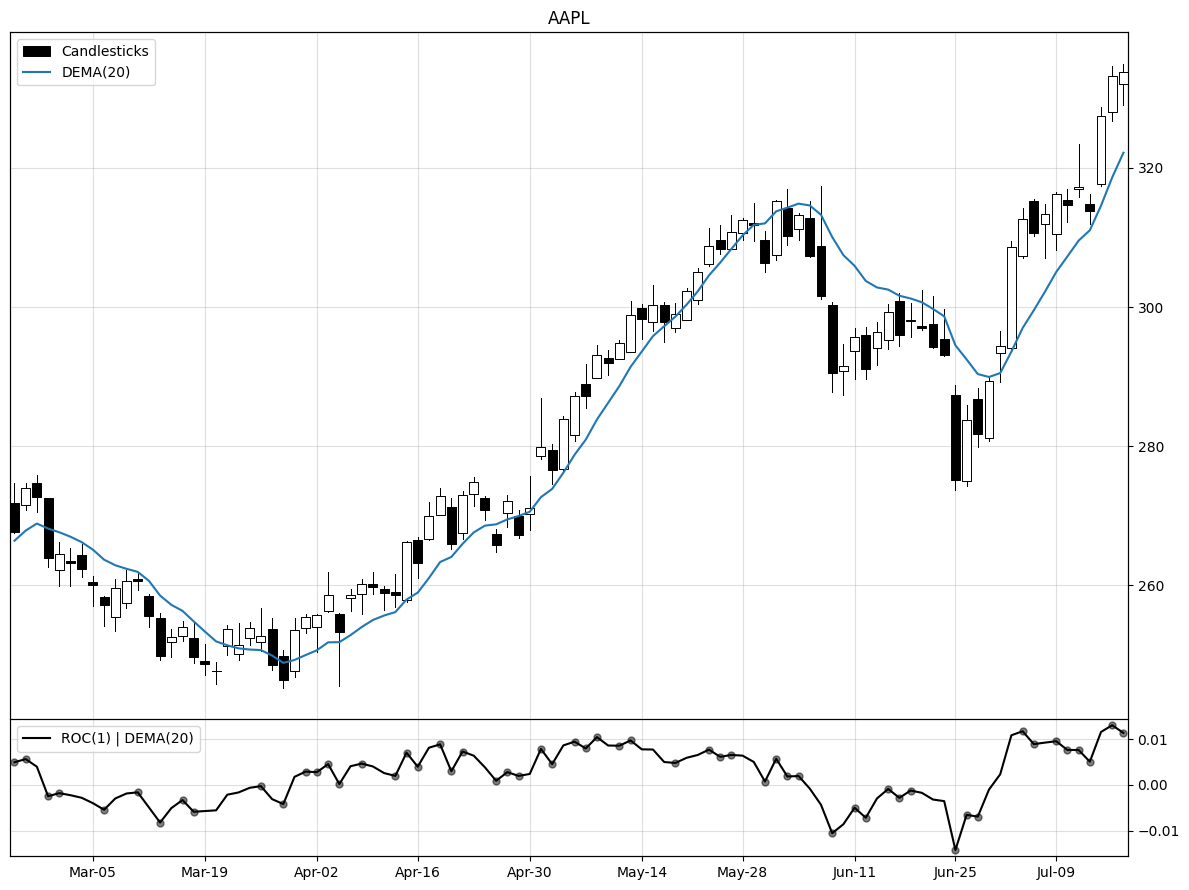

In [4]:
roc_smooth = ROC(1) | DEMA(20)

Chart(prices, title=ticker, max_bars=100).plot(
    Candlesticks(),
    DEMA(20),
).pane("below").plot(
    roc_smooth,
    Swings(roc_smooth, span=1),
).show()